# 02. 결과 분석

모델 비교와 선정 근거, 피크 예측 성능, 오류 분석을 정리한다. `python run.py`의 결과(`outputs/`)를 사용한다.

피크 지표는 일자별 상위 K개(기본 10개) 15분 구간으로 정의한다.
- `top10_hit`: 예측 상위 10개 구간 중 실제 상위 10개에 포함된 비율(순위 무관, 실제값 동률은 모두 포함)
- `top10_mae`: 실제·예측 상위 10개 값을 각각 내림차순 정렬해 순위끼리 비교한 MAE(발생 시각과 무관한 피크 수준 오차)

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as C
from src.experiment import wavg, error_slices
from src.metrics import K, HIT_COL, TOPK_MAE_COL, daily_matrix, topk_scores, topk_hits_within
from src.report import cv_summary, lookback_table
from src.viz import setup_plot_style, DOW_KR

setup_plot_style()
pd.set_option("display.max_columns", 50)
OUT = ROOT / C.OUTPUT_DIR

required = ["metrics_cv.csv", "metrics_test.csv", "predictions_test.csv", "run_info.json"]
missing = [f for f in required if not (OUT / f).exists()]
if missing:
    raise FileNotFoundError(f"run.py 실행 결과가 없습니다: {missing}")

cv = pd.read_csv(OUT / "metrics_cv.csv")
test = pd.read_csv(OUT / "metrics_test.csv")
preds = pd.read_csv(OUT / "predictions_test.csv", parse_dates=["ts", "date"])
info = json.loads((OUT / "run_info.json").read_text(encoding="utf-8"))
selected = info["selected_model"]
print("GBM 백엔드:", info["gbm_backend"], "/ 선정 모델:", selected)

GBM 백엔드: lightgbm 4.7.0 / 선정 모델: lstm_1d


## 1. 교차검증

7/5부터 주 단위 walk-forward 7개 폴드. 폴드별 지표를 채점일 수로 가중평균한다. 선정 기준은 점예측 모델 중 CV MAE 최소이다.

,model,kind,lookback,mae,rmse,daily_max_mae,top10_hit,top10_mae,mae_std_across_folds
3,lstm_1d,point,1d,18.209,27.819,30.831,0.367,28.173,15.388
4,lstm_7d,point,7d,21.788,34.370,34.337,0.377,31.476,16.980
1,gbm_1d,point,1d,23.749,35.389,36.879,0.354,32.911,10.015
0,gbm,point,7d,24.696,33.500,41.953,0.381,38.149,18.684
8,random_forest,point,7d,26.932,38.458,45.521,0.337,41.391,22.940
2,gbm_q80,risk,7d,29.482,38.655,40.564,0.375,36.451,25.803
7,profile_mean,point,7d,30.587,37.101,48.552,0.396,45.094,19.950
5,naive_lastweek,point,7d,32.274,43.940,48.062,0.321,44.752,34.845
6,naive_yesterday,point,1d,34.890,55.539,48.208,0.252,44.215,16.129


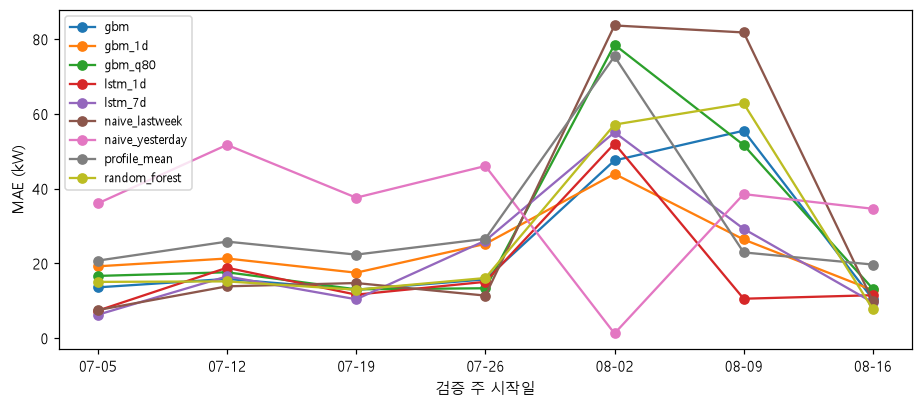

In [2]:
cv_mean = cv_summary(cv)
display(cv_mean[["model", "kind", "lookback", "mae", "rmse", "daily_max_mae", HIT_COL, TOPK_MAE_COL,
                 "mae_std_across_folds"]].round(3))

ax = cv.pivot(index="fold", columns="model", values="mae").plot(marker="o", figsize=(10, 4))
ax.set_ylabel("MAE (kW)")
ax.set_xlabel("검증 주 시작일")
ax.legend(fontsize=8)
plt.show()

08-02, 08-09 폴드는 휴가 주간과 그다음 주로, 7일 전 값에 의존하는 모델의 오차가 크게 증가한다.

## 2. 입력 범위 비교 (1d / 7d)

학습 데이터는 모두 예측일 이전 전체이며, 예측 시 입력으로 사용하는 과거 범위만 다르다.

,family,lookback,model,cv_mae,cv_top10_hit,test_mae,test_top10_hit
2,gbm,1d,gbm_1d,23.749,0.354,18.884,0.439
3,gbm,7d,gbm,24.696,0.381,12.558,0.439
4,lstm,1d,lstm_1d,18.209,0.367,9.256,0.448
5,lstm,7d,lstm_7d,21.788,0.377,8.432,0.413
0,naive,1d,naive_yesterday,34.890,0.252,40.459,0.296
1,naive,7d,naive_lastweek,32.274,0.321,10.202,0.352


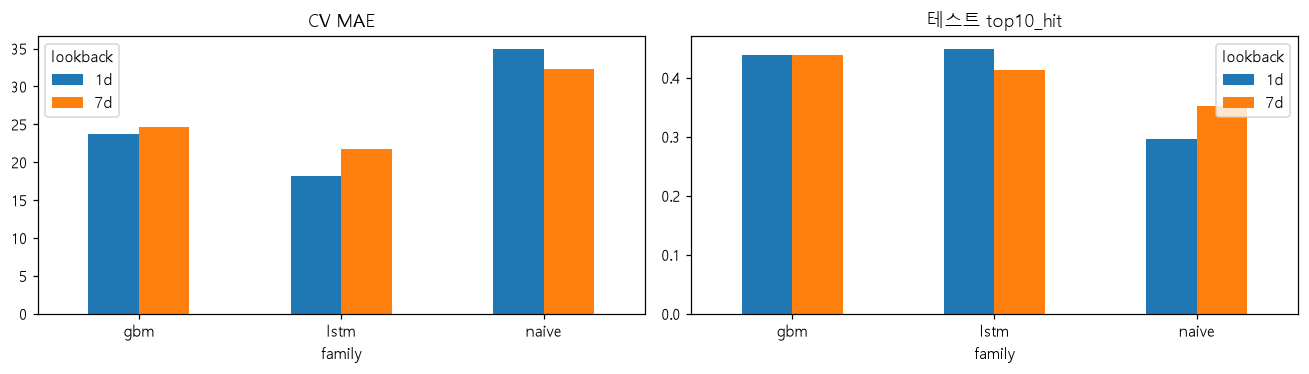

In [3]:
lb = lookback_table(cv_mean, test)
display(lb.round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, col, title in [(axes[0], "cv_mae", "CV MAE"), (axes[1], f"test_{HIT_COL}", f"테스트 {HIT_COL}")]:
    lb.pivot(index="family", columns="lookback", values=col).plot(kind="bar", ax=ax, rot=0)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 3. 최종 테스트 (8/23~9/14)

,model,kind,lookback,mae,rmse,nmae,bias,daily_max_mae,daily_max_bias,top10_hit,top10_mae
0,naive_yesterday,point,1d,40.459,64.322,0.392,-4.775,53.783,-6.826,0.296,52.578
1,naive_lastweek,point,7d,10.202,14.345,0.099,-1.279,8.565,-1.000,0.352,7.404
2,profile_mean,point,7d,19.669,23.439,0.190,-6.835,29.405,-21.484,0.487,26.191
3,random_forest,point,7d,10.554,16.479,0.102,-0.537,18.160,-14.482,0.439,14.357
4,gbm_1d,point,1d,18.884,26.846,0.183,3.298,24.170,-12.731,0.439,22.294
5,gbm,point,7d,12.558,19.387,0.122,-1.089,18.287,-14.136,0.439,15.805
6,gbm_q80,risk,7d,14.394,20.599,0.139,9.811,11.945,-0.879,0.461,11.469
7,lstm_1d,point,1d,9.256,12.785,0.090,-1.099,13.705,-13.705,0.448,10.825
8,lstm_7d,point,7d,8.432,12.186,0.082,-1.042,10.648,-10.220,0.413,8.185


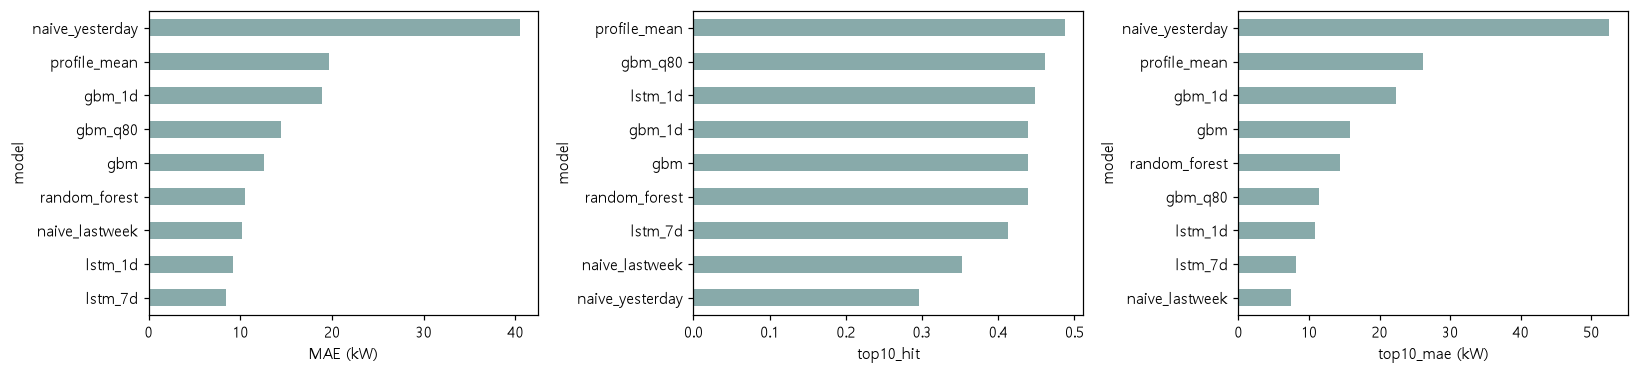

In [4]:
display(test[["model", "kind", "lookback", "mae", "rmse", "nmae", "bias", "daily_max_mae", "daily_max_bias",
              HIT_COL, TOPK_MAE_COL]].round(3))
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
t = test.set_index("model")
for ax, col, xlabel in [(axes[0], "mae", "MAE (kW)"), (axes[1], HIT_COL, HIT_COL), (axes[2], TOPK_MAE_COL, f"{TOPK_MAE_COL} (kW)")]:
    t[col].sort_values().plot(kind="barh", ax=ax, color="#8aa")
    ax.set_xlabel(xlabel)
plt.tight_layout()
plt.show()

테스트 구간은 정상 운영 주간으로만 구성되어 휴가 주간이 포함된 CV보다 오차가 작다.

## 4. Ablation, 분할 단위 비교

In [5]:
for name, title in [("ablation_cv.csv", "설정별 비교 (GBM, CV)"), ("leakage_demo.csv", "무작위 분할 단위별 MAE (GBM)")]:
    path = OUT / name
    if path.exists():
        print(title)
        display(pd.read_csv(path).round(3))

설정별 비교 (GBM, CV)


,variant,mae,nmae,daily_max_mae,top10_hit,top10_mae
0,baseline (config),24.696,0.498,41.953,0.381,38.149
1,copy days dropped,24.261,0.566,38.019,0.396,34.469
2,copy days weighted 1/n,25.305,0.523,42.186,0.396,38.493
3,production plan: daily total,23.594,0.464,36.932,0.383,33.576
4,production plan: hourly,20.606,0.388,32.432,0.342,29.531
5,weather: on,25.886,0.532,41.093,0.337,37.820
6,hourly plan + weather,19.384,0.383,30.920,0.321,27.319


무작위 분할 단위별 MAE (GBM)


,split,mae,nmae,n_test_rows
0,random rows (80/20),9.537,0.101,4800
1,random days (80/20),15.907,0.156,4800
2,random duplicate-groups (80/20),22.222,0.239,4320


## 5. 테스트 예측

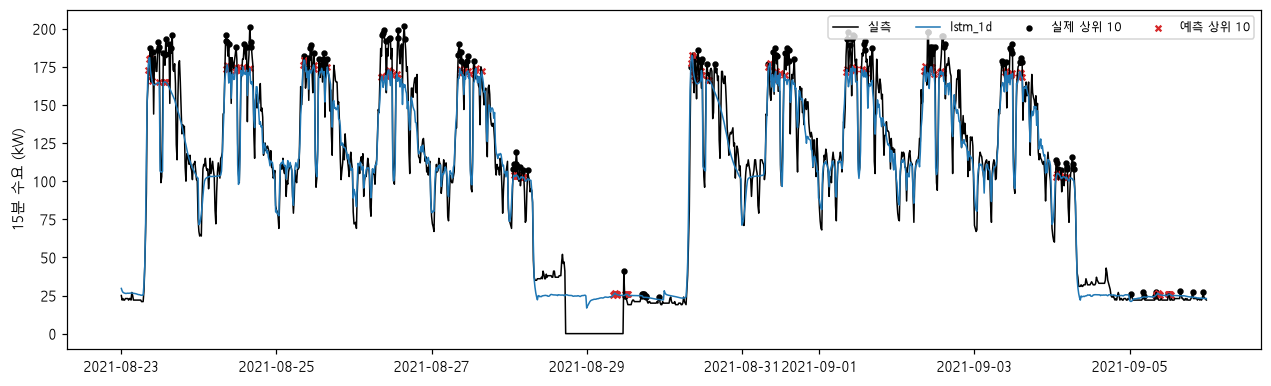

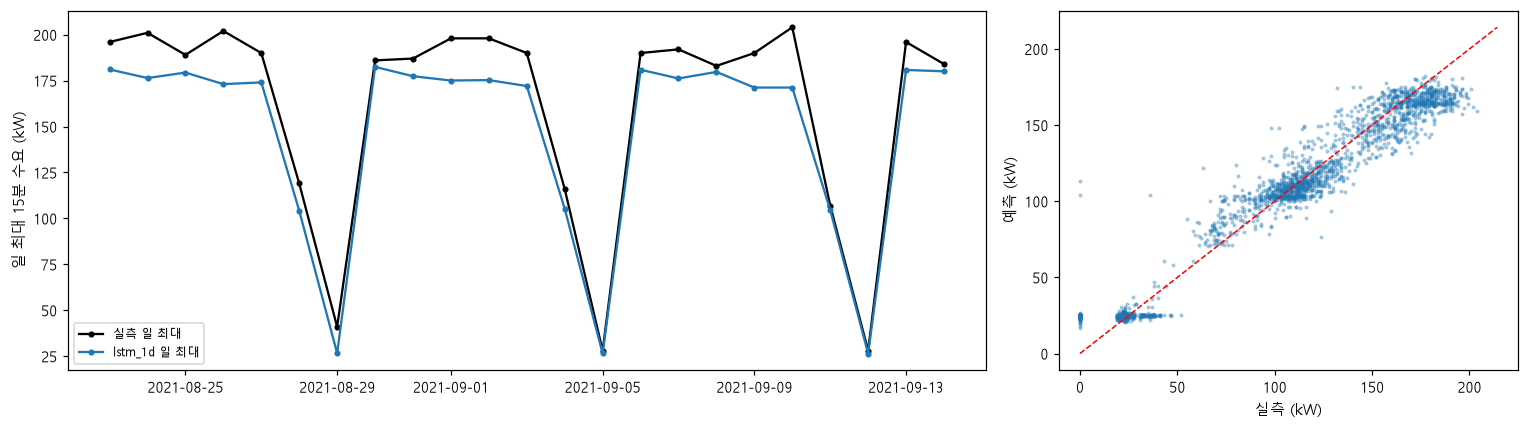

In [6]:
w = preds[preds["ts"] < preds["ts"].min().normalize() + pd.Timedelta(days=14)].reset_index(drop=True)
a = daily_matrix(w, "kw").to_numpy()
p = daily_matrix(w, selected).to_numpy()
pos = lambda m: (np.arange(len(m))[:, None] * 96 + np.argsort(-m, axis=1, kind="stable")[:, :K]).ravel()
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(w["ts"], w["kw"], color="black", lw=1, label="실측")
ax.plot(w["ts"], w[selected], lw=1, label=selected)
ax.scatter(w.loc[pos(a), "ts"], w.loc[pos(a), "kw"], s=10, color="black", label=f"실제 상위 {K}")
ax.scatter(w.loc[pos(p), "ts"], w.loc[pos(p), selected], s=14, marker="x", color="tab:red", label=f"예측 상위 {K}")
ax.set_ylabel("15분 수요 (kW)")
ax.legend(ncol=4, fontsize=8, loc="upper right")
plt.show()

daily = preds.groupby("date")[["kw", selected]].max()
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(daily.index, daily["kw"], "o-", color="black", ms=3, label="실측 일 최대")
axes[0].plot(daily.index, daily[selected], "o-", ms=3, label=f"{selected} 일 최대")
axes[0].set_ylabel("일 최대 15분 수요 (kW)")
axes[0].legend(fontsize=8)
axes[1].scatter(preds["kw"], preds[selected], s=3, alpha=0.3)
lim = [0, preds["kw"].max() * 1.05]
axes[1].plot(lim, lim, "r--", lw=1)
axes[1].set_xlabel("실측 (kW)")
axes[1].set_ylabel("예측 (kW)")
plt.tight_layout()
plt.show()

트리 모델은 잎에 속한 학습 타깃의 평균을 출력하므로 극단값이 완화되어 일 최대수요가 낮게 예측되는 경향(`daily_max_bias` 음수)이 있다.

## 6. 오류 분석

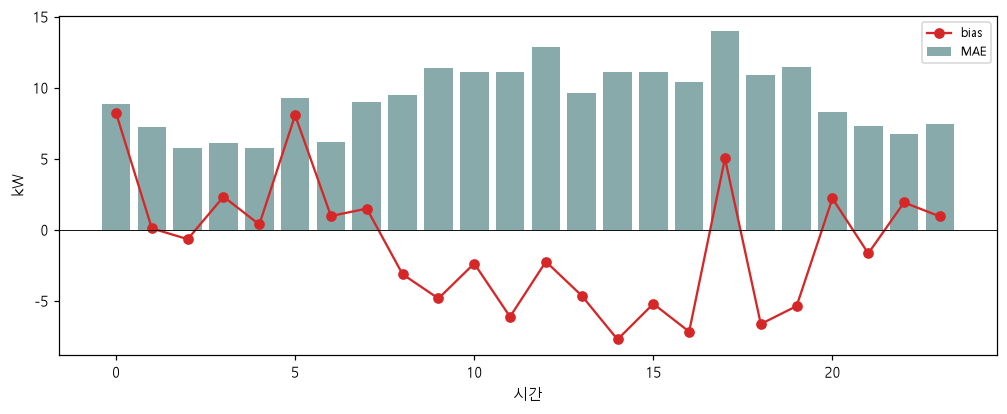

,dow,mae,bias,n,top10_hits,top10_mae,요일
0,1,10.23,-2.48,384,5.00,12.93,월
1,2,10.07,-4.24,384,4.75,11.27,화
2,3,10.65,0.72,288,4.33,9.63,수
3,4,10.40,-5.42,288,4.00,19.28,목
4,5,8.56,-1.32,288,5.00,14.73,금
5,6,8.87,1.73,288,6.33,5.67,토
6,7,5.41,4.82,288,1.67,1.42,일


,prod_bin,mae,bias,n
0,0,6.50,3.47,648
1,1-500,9.09,0.15,784
2,501-1500,11.72,-6.10,544
3,>1500,11.76,-6.35,232


In [7]:
sl = error_slices(preds, selected)
h = sl["by_hour"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(h["hour"], h["mae"], color="#8aa", label="MAE")
ax.plot(h["hour"], h["bias"], "o-", color="tab:red", label="bias")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("시간")
ax.set_ylabel("kW")
ax.legend(fontsize=8)
plt.show()

display(sl["by_dow"].assign(요일=lambda d: d["dow"].map(DOW_KR)).round(2))
display(sl["by_prod"].round(2))

### 피크 시간대 적중

실제 상위 10개 구간과 예측 상위 10개 구간의 시간 분포를 비교한다.

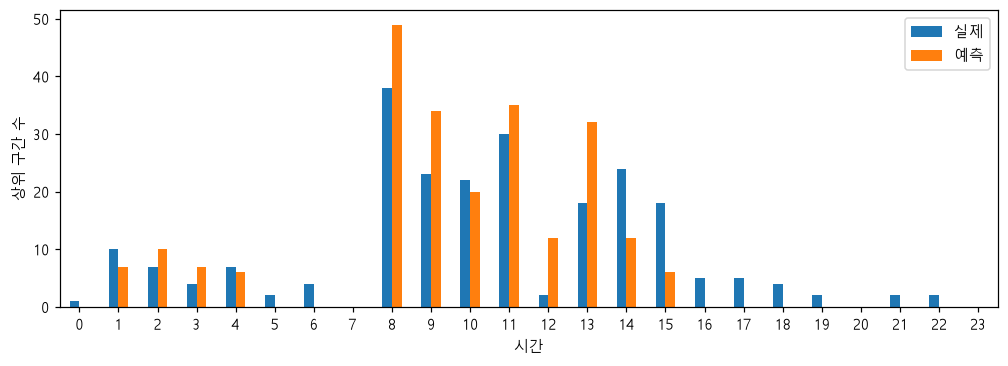

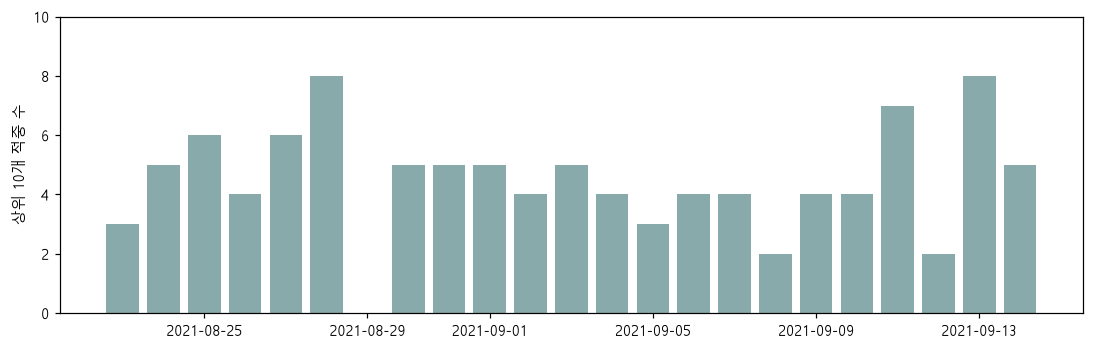

C:\Users\82105\AppData\Local\Temp\ipykernel_14060\2098012844.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(bd.sort_values(f"top{K}_hits").head(8).round(2))


,date,dow,mae,top10_hits,top10_mae,daily_max_err,요일
6,2021-08-29,7,12.92,0,2.06,-14.41,일
16,2021-09-08,3,13.89,2,3.00,-3.29,수
20,2021-09-12,7,1.45,2,1.40,-1.55,일
0,2021-08-23,1,10.98,3,18.55,-14.94,월
13,2021-09-05,7,1.86,3,0.79,-1.48,일
12,2021-09-04,6,6.49,4,6.90,-10.71,토
14,2021-09-06,1,8.19,4,6.93,-9.09,월
3,2021-08-26,4,11.88,4,25.82,-28.92,목


In [8]:
A = daily_matrix(preds, "kw")
P = daily_matrix(preds, selected)
top_a = np.argsort(-A.to_numpy(), axis=1, kind="stable")[:, :K] // 4
top_p = np.argsort(-P.to_numpy(), axis=1, kind="stable")[:, :K] // 4
dist = pd.DataFrame({"실제": np.bincount(top_a.ravel(), minlength=24),
                     "예측": np.bincount(top_p.ravel(), minlength=24)})
ax = dist.plot(kind="bar", figsize=(11, 3.5), rot=0)
ax.set_xlabel("시간")
ax.set_ylabel("상위 구간 수")
plt.show()

bd = sl["by_day"].assign(요일=lambda d: d["dow"].map(DOW_KR))
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(pd.to_datetime(bd["date"]), bd[f"top{K}_hits"], color="#8aa")
ax.set_ylim(0, K)
ax.set_ylabel(f"상위 {K}개 적중 수")
plt.show()
display(bd.sort_values(f"top{K}_hits").head(8).round(2))

### 피크 시간대 적중 (±30분 허용)

예측 상위 10개 구간이 같은 날 실제 상위 10개 구간과 ±30분(15분 구간 2개) 이내이면 적중으로 본다. 테스트 구간 기준이다.

In [ ]:
tol = C.PEAK_HIT_TOL_SLOTS
tol_col = f"{HIT_COL}_±{15 * tol}분"
act = daily_matrix(preds, "kw").to_numpy()
rows = []
for m in test["model"]:
    pm = daily_matrix(preds, m).to_numpy()
    rows.append({"model": m,
                 HIT_COL: (topk_hits_within(act, pm) / K).mean(),
                 tol_col: (topk_hits_within(act, pm, tol=tol) / K).mean()})
hit_tol = pd.DataFrame(rows).set_index("model").sort_values(tol_col)
display(hit_tol.round(3))

ax = hit_tol.plot(kind="barh", figsize=(8, 3.5), color=["#8aa", "tab:blue"])
ax.set_xlim(0, 1)
ax.set_xlabel("적중률")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.show()